# 🏥 Insurance Charges — Regresión y Selección de Modelos
---

## 📌 Contexto

Este proyecto analiza un dataset de seguros médicos en Estados Unidos con el objetivo de **predecir el costo individual de un seguro** (`charges`) a partir de variables demográficas y de estilo de vida.

## 🎯 Objetivo

Encontrar el **mejor modelo de regresión** evaluando múltiples algoritmos con validación cruzada, usando un pipeline de preprocesamiento automatizado para garantizar reproducibilidad y evitar data leakage.

## 🗂️ Dataset

| Campo | Descripción |
|-------|-------------|
| `age` | Edad del asegurado |
| `sex` | Sexo |
| `bmi` | Índice de masa corporal |
| `children` | Número de hijos cubiertos |
| `smoker` | Si el asegurado fuma |
| `region` | Región de EE.UU. |
| `charges` | 🎯 **Target** — Costo del seguro en USD |

## ⚙️ Modelos evaluados

`LinearRegression` · `Ridge` · `Lasso` · `RandomForestRegressor` · `GradientBoostingRegressor`

## 🧱 Stack técnico

`pandas` · `numpy` · `scikit-learn` · `seaborn` · `matplotlib`

---


# **1. Librerías**


In [1]:
# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Scaler & Data split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, OneHotEncoder
from sklearn.model_selection import train_test_split, GridSearchCV

# Math & Dataframes
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# ML Workflow
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

import warnings
warnings.filterwarnings('ignore')

# **2. Carga de datos**

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv')

# **3. EDA**

In [3]:
# Filas y columnas
df.shape

(1338, 7)

In [4]:
# Elementos faltantes
print(f'Elementos faltantes: {df.isna().sum().sum()}')
print(f'Elementos duplicados: {df.duplicated().sum()}')

Elementos faltantes: 0
Elementos duplicados: 1


# _No tenemos faltantes, pero sí tenemos un elemento duplicado para eliminar_

In [5]:
df = df.drop_duplicates()

In [6]:
# Vistazo rápido de datos estadísticos principales
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
# Tipos de datos
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [8]:
# Columnas con datos numéricos
df.select_dtypes(include='number').columns

Index(['age', 'bmi', 'children', 'charges'], dtype='object')

In [9]:
# Columnas con datos categóricos
df.select_dtypes(include='object').columns

Index(['sex', 'smoker', 'region'], dtype='object')

In [10]:
# Correlaciones entre los datos numéricos
corr_numericos = df[df.select_dtypes(include='number').columns].corr()
corr_numericos

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


In [34]:
df.head()

,age,sex,bmi,children,smoker,region,charges,bmi_grupo,segmento,grupo_edad
0,19,female,27.900,0,yes,southwest,16884.92400,25-30,Fumador / BMI 25-30,Joven (18-30)
1,18,male,33.770,1,no,southeast,1725.55230,30-35,No fumador / BMI 30-35,Joven (18-30)
2,28,male,33.000,3,no,southeast,4449.46200,30-35,No fumador / BMI 30-35,Joven (18-30)
3,33,male,22.705,0,no,northwest,21984.47061,<25,No fumador / BMI <25,Adulto (31-50)
4,32,male,28.880,0,no,northwest,3866.85520,25-30,No fumador / BMI 25-30,Adulto (31-50)


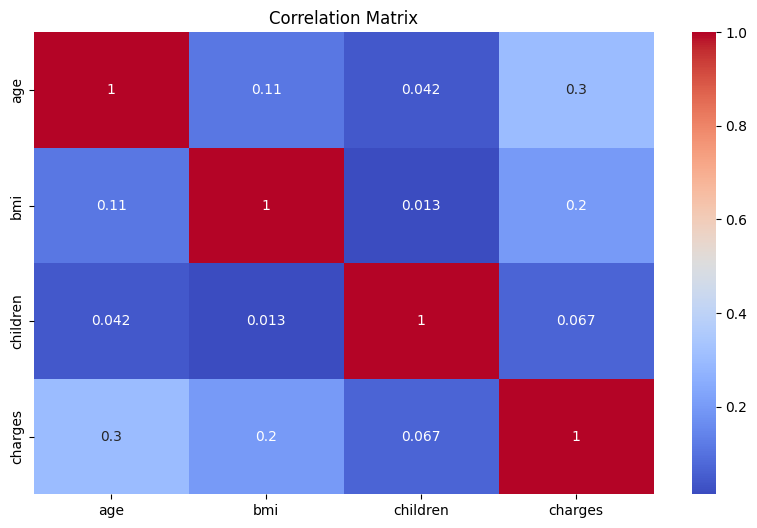

In [11]:
# Heatmap para ver correlaciones
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_numericos,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

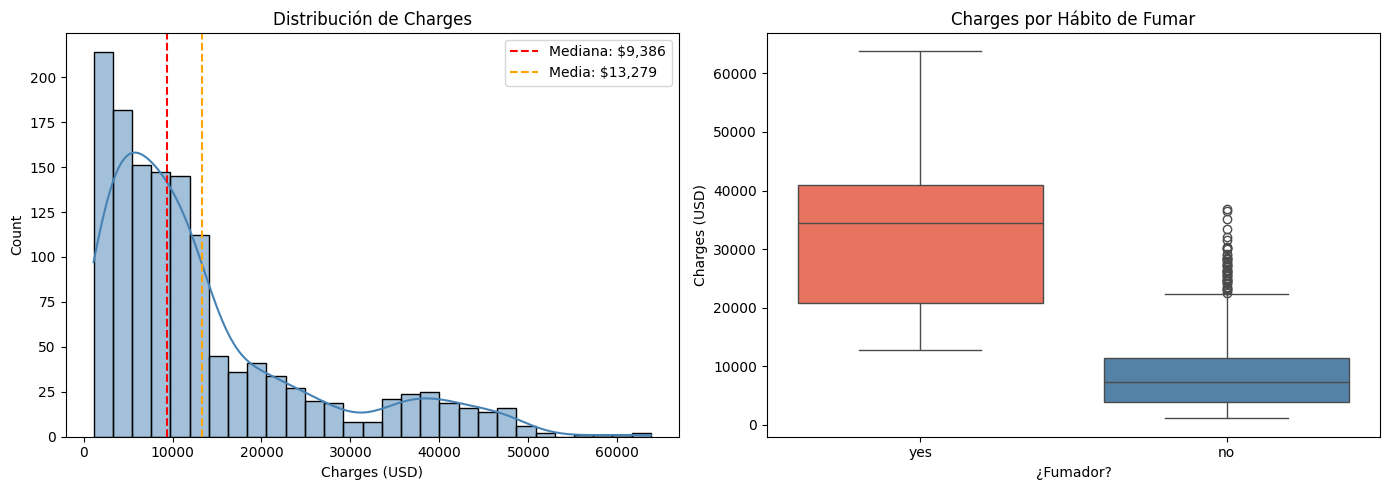

In [12]:
# --- Distribución del target ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma con KDE
sns.histplot(df["charges"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribución de Charges")
axes[0].set_xlabel("Charges (USD)")
axes[0].axvline(df["charges"].median(), color="red", linestyle="--", label=f"Mediana: ${df['charges'].median():,.0f}")
axes[0].axvline(df["charges"].mean(), color="orange", linestyle="--", label=f"Media: ${df['charges'].mean():,.0f}")
axes[0].legend()

# Boxplot por fumador
sns.boxplot(x="smoker", y="charges", data=df, ax=axes[1],
            palette={"yes": "tomato", "no": "steelblue"})
axes[1].set_title("Charges por Hábito de Fumar")
axes[1].set_xlabel("¿Fumador?")
axes[1].set_ylabel("Charges (USD)")

plt.tight_layout()
plt.show()

In [13]:
# Cuantificar el impacto del tabaquismo
mediana_fumador    = df[df["smoker"] == "yes"]["charges"].median()
mediana_nofumador  = df[df["smoker"] == "no"]["charges"].median()
multiplicador      = mediana_fumador / mediana_nofumador

print(f"Mediana charges fumadores    : ${mediana_fumador:,.2f}")
print(f"Mediana charges no fumadores : ${mediana_nofumador:,.2f}")
print(f"Los fumadores pagan en mediana {multiplicador:.1f}x más que los no fumadores.")

Mediana charges fumadores    : $34,456.35
Mediana charges no fumadores : $7,345.73
Los fumadores pagan en mediana 4.7x más que los no fumadores.


In [15]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


# **Insights revelados en el análisis**

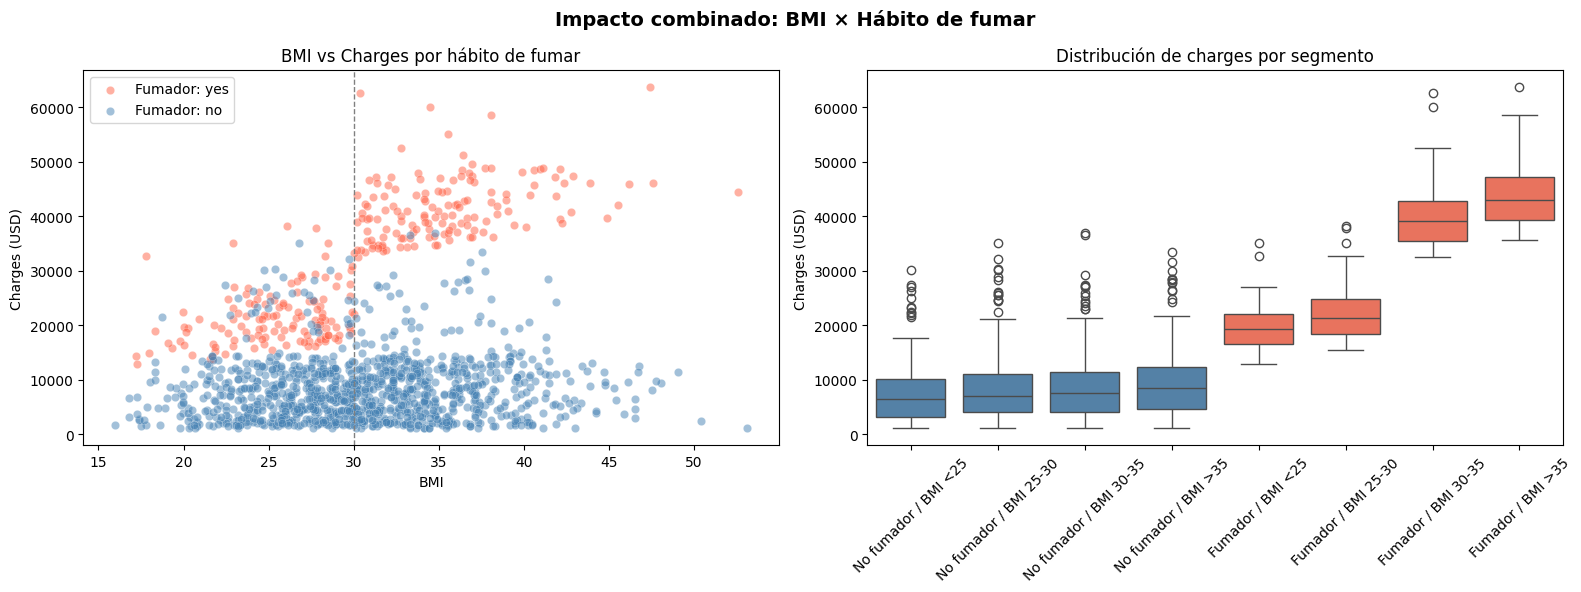


📊 Mediana de charges por segmento:
bmi_grupo           <25       25-30        30-35         >35
smoker                                                      
no          6497.899825   7046.7222   7682.67000   8527.5320
yes        19361.998800  21348.7060  39125.33225  42969.8527

💡 Insight:
   Un fumador con BMI≥30 paga en mediana $40,904
   Un no fumador con BMI<25 paga en mediana $6,337
   → Diferencia: 6.5x más caro


In [16]:
# =========================================================
# INSIGHT 1: Impacto combinado de fumador + BMI sobre charges
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Impacto combinado: BMI × Hábito de fumar", fontsize=14, fontweight="bold")

# --- Gráfico 1: Scatter BMI vs Charges coloreado por smoker ---
colores = {"yes": "tomato", "no": "steelblue"}

for grupo, color in colores.items():
    subset = df[df["smoker"] == grupo]
    axes[0].scatter(
        subset["bmi"], subset["charges"],
        c=color, alpha=0.5, label=f"Fumador: {grupo}",
        edgecolors="white", linewidth=0.3
    )

axes[0].set_xlabel("BMI")
axes[0].set_ylabel("Charges (USD)")
axes[0].set_title("BMI vs Charges por hábito de fumar")
axes[0].legend()
axes[0].axvline(30, color="gray", linestyle="--", linewidth=1, label="BMI=30 (obesidad)")

# --- Gráfico 2: Boxplot de 4 segmentos cruzados ---
df["bmi_grupo"] = pd.cut(df["bmi"], bins=[0, 25, 30, 35, 100],
                          labels=["<25", "25-30", "30-35", ">35"])
df["segmento"] = df["smoker"].map({"yes": "Fumador", "no": "No fumador"}) + \
                 " / BMI " + df["bmi_grupo"].astype(str)

orden = [f"{s} / BMI {b}" for s in ["No fumador", "Fumador"]
         for b in ["<25", "25-30", "30-35", ">35"]]

palette = {seg: "tomato" if "Fumador" in seg else "steelblue" for seg in orden}

sns.boxplot(
    data=df[df["segmento"].isin(orden)],
    x="segmento", y="charges",
    order=orden, palette=palette, ax=axes[1]
)

axes[1].set_title("Distribución de charges por segmento")
axes[1].set_xlabel("")
axes[1].set_ylabel("Charges (USD)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

# --- Estadísticas clave ---
print("\n📊 Mediana de charges por segmento:")
resumen = df.groupby(["smoker", "bmi_grupo"])["charges"].median().unstack()
print(resumen.to_string())

print("\n💡 Insight:")
med_fum_obeso   = df[(df["smoker"] == "yes") & (df["bmi"] >= 30)]["charges"].median()
med_nofum_normal = df[(df["smoker"] == "no") & (df["bmi"] < 25)]["charges"].median()
print(f"   Un fumador con BMI≥30 paga en mediana ${med_fum_obeso:,.0f}")
print(f"   Un no fumador con BMI<25 paga en mediana ${med_nofum_normal:,.0f}")
print(f"   → Diferencia: {med_fum_obeso / med_nofum_normal:.1f}x más caro")

# **_En el gráfico anterior se puede apreciar claramente como impacta la combinación de BMI alto con tabaquismo en el cargo del seguro._**

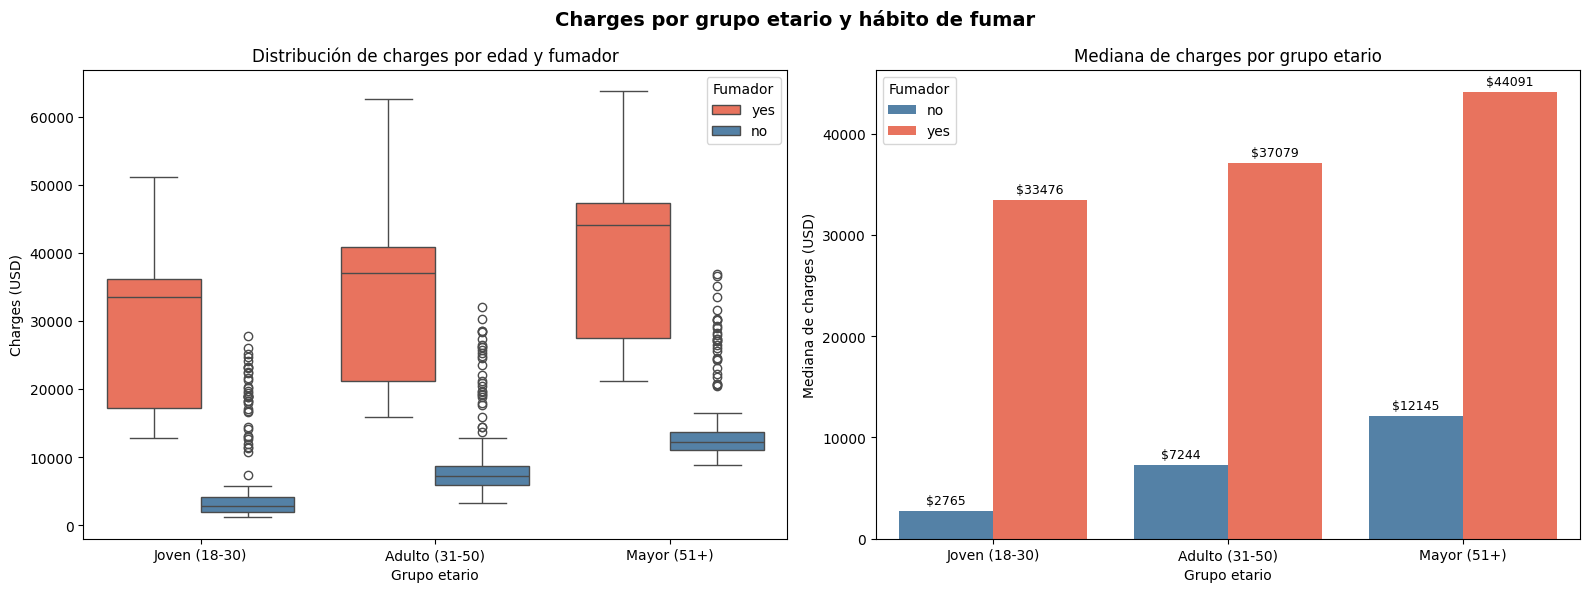


📊 Mediana de charges por grupo etario y hábito de fumar:
                           Mediana         Media    N
grupo_edad     smoker                                
Joven (18-30)  no       2765.10655   4470.419842  348
               yes     33475.81715  27528.078343   95
Adulto (31-50) no       7243.81360   8186.653963  423
               yes     37079.37200  32018.276539  115
Mayor (51+)    no      12144.77480  13540.277993  292
               yes     44090.96680  38820.223082   64

💡 Insight:
   Joven (18-30): fumadores pagan 12.1x más que no fumadores
   Adulto (31-50): fumadores pagan 5.1x más que no fumadores
   Mayor (51+): fumadores pagan 3.6x más que no fumadores


In [17]:
# =========================================================
# INSIGHT 2: Segmentación por grupos etarios × fumador
# =========================================================

df["grupo_edad"] = pd.cut(
    df["age"],
    bins=[17, 30, 50, 100],
    labels=["Joven (18-30)", "Adulto (31-50)", "Mayor (51+)"]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Charges por grupo etario y hábito de fumar", fontsize=14, fontweight="bold")

# --- Gráfico 1: Boxplot por edad coloreado por smoker ---
sns.boxplot(
    data=df, x="grupo_edad", y="charges", hue="smoker",
    palette={"yes": "tomato", "no": "steelblue"},
    ax=axes[0]
)
axes[0].set_title("Distribución de charges por edad y fumador")
axes[0].set_xlabel("Grupo etario")
axes[0].set_ylabel("Charges (USD)")
axes[0].legend(title="Fumador")

# --- Gráfico 2: Barplot de mediana por grupo ---
mediana_grupo = df.groupby(["grupo_edad", "smoker"])["charges"].median().reset_index()

sns.barplot(
    data=mediana_grupo,
    x="grupo_edad", y="charges", hue="smoker",
    palette={"yes": "tomato", "no": "steelblue"},
    ax=axes[1]
)
axes[1].set_title("Mediana de charges por grupo etario")
axes[1].set_xlabel("Grupo etario")
axes[1].set_ylabel("Mediana de charges (USD)")
axes[1].legend(title="Fumador")

# Añadir etiquetas de valor en las barras
for container in axes[1].containers:
    axes[1].bar_label(container, fmt="$%.0f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()

# --- Estadísticas clave ---
print("\n📊 Mediana de charges por grupo etario y hábito de fumar:")
tabla = df.groupby(["grupo_edad", "smoker"])["charges"].agg(["median", "mean", "count"])
tabla.columns = ["Mediana", "Media", "N"]
print(tabla.to_string())

print("\n💡 Insight:")
for grupo in df["grupo_edad"].cat.categories:
    med_fum  = df[(df["grupo_edad"] == grupo) & (df["smoker"] == "yes")]["charges"].median()
    med_nofum = df[(df["grupo_edad"] == grupo) & (df["smoker"] == "no")]["charges"].median()
    print(f"   {grupo}: fumadores pagan {med_fum/med_nofum:.1f}x más que no fumadores")

# **_Es innegable que el costo del seguro tiende a aumentar con la edad, y si agregamos el tabaquismo a la ecuación, el valor se dispara aún más rápidamente._**

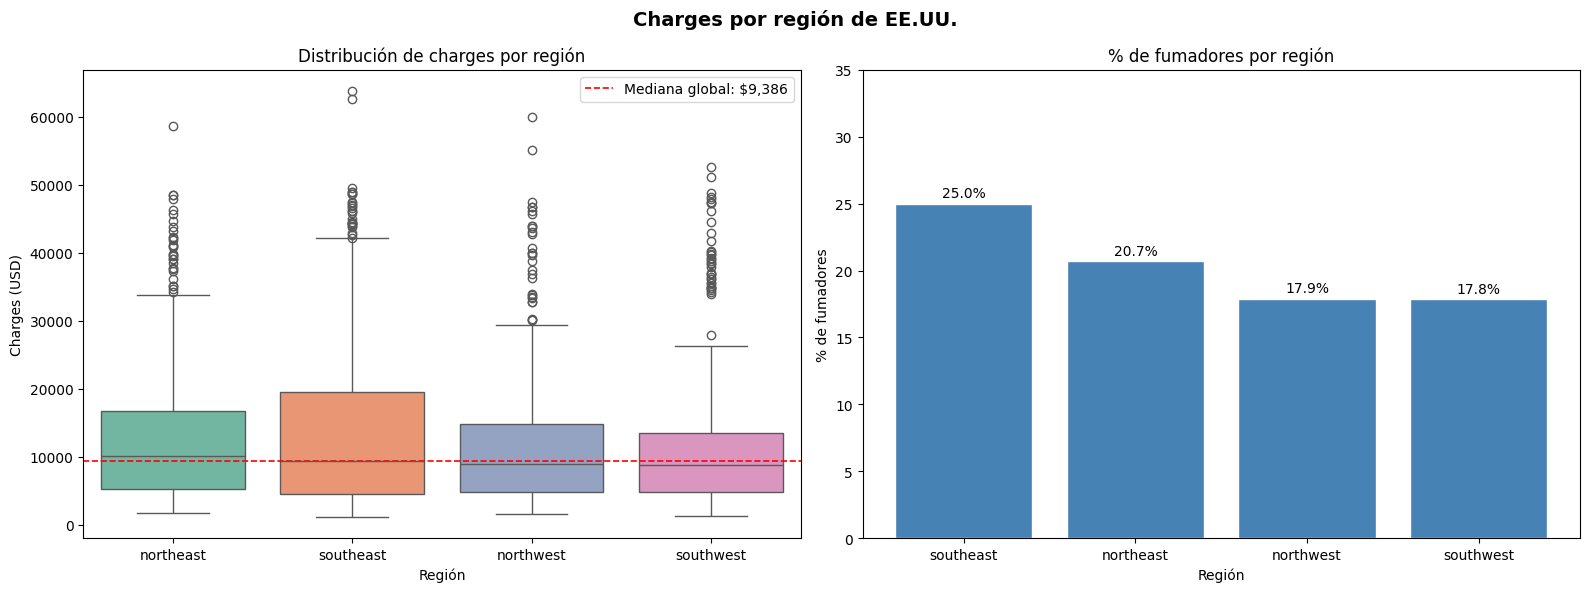


📊 Estadísticas por región:
                Mediana         Media    Desv. Est.    N
region                                                  
northeast  10057.652025  13406.384516  11255.803066  324
southeast   9294.131950  14735.411438  13971.098589  364
northwest   8976.977250  12450.840844  11073.125699  324
southwest   8798.593000  12346.937377  11557.179101  325

💡 Insight:
   La región con mayor costo mediano es 'northeast'
   La región con menor costo mediano es 'southwest'
   → Diferencia: 1.14x entre ambas regiones


In [18]:
# =========================================================
# INSIGHT 3: Diferencias geográficas por región
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Charges por región de EE.UU.", fontsize=14, fontweight="bold")

# --- Gráfico 1: Boxplot por región ---
orden_region = df.groupby("region")["charges"].median().sort_values(ascending=False).index

sns.boxplot(
    data=df, x="region", y="charges",
    order=orden_region,
    palette="Set2",
    ax=axes[0]
)
axes[0].set_title("Distribución de charges por región")
axes[0].set_xlabel("Región")
axes[0].set_ylabel("Charges (USD)")

# Línea de mediana global
mediana_global = df["charges"].median()
axes[0].axhline(mediana_global, color="red", linestyle="--", linewidth=1.2,
                label=f"Mediana global: ${mediana_global:,.0f}")
axes[0].legend()

# --- Gráfico 2: % de fumadores por región (puede explicar diferencias de costo) ---
pct_fumadores = df.groupby("region")["smoker"].apply(
    lambda x: (x == "yes").sum() / len(x) * 100
).reset_index()
pct_fumadores.columns = ["region", "pct_fumadores"]
pct_fumadores = pct_fumadores.sort_values("pct_fumadores", ascending=False)

bars = axes[1].bar(
    pct_fumadores["region"],
    pct_fumadores["pct_fumadores"],
    color="steelblue",
    edgecolor="white"
)
axes[1].set_title("% de fumadores por región")
axes[1].set_xlabel("Región")
axes[1].set_ylabel("% de fumadores")
axes[1].set_ylim(0, 35)

for bar, val in zip(bars, pct_fumadores["pct_fumadores"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"{val:.1f}%", ha="center", fontsize=10)

plt.tight_layout()
plt.show()

# --- Estadísticas clave ---
print("\n📊 Estadísticas por región:")
resumen_region = df.groupby("region")["charges"].agg(["median", "mean", "std", "count"])
resumen_region.columns = ["Mediana", "Media", "Desv. Est.", "N"]
resumen_region = resumen_region.sort_values("Mediana", ascending=False)
print(resumen_region.to_string())

print("\n💡 Insight:")
max_region = resumen_region.index[0]
min_region = resumen_region.index[-1]
diff = resumen_region.loc[max_region, "Mediana"] / resumen_region.loc[min_region, "Mediana"]
print(f"   La región con mayor costo mediano es '{max_region}'")
print(f"   La región con menor costo mediano es '{min_region}'")
print(f"   → Diferencia: {diff:.2f}x entre ambas regiones")

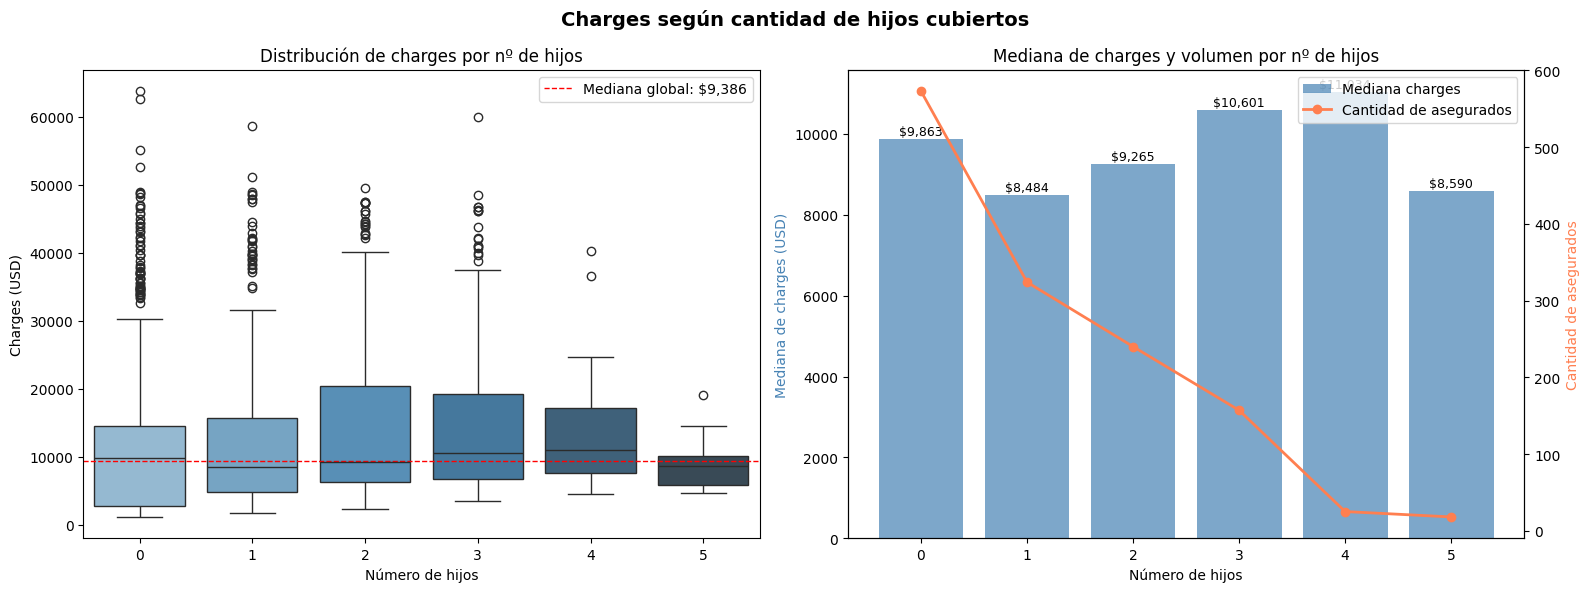


📊 Mediana de charges por nº de hijos:
 children     mediana  count
        0  9863.47180    573
        1  8483.87015    324
        2  9264.97915    240
        3 10600.54830    157
        4 11033.66170     25
        5  8589.56505     18

💡 Insight:
   El grupo con 0 hijos tiene mediana $9,863
   El grupo con 3 hijos tiene mediana $10,601
   A partir de 3+ hijos la mediana tiende a estabilizarse o bajar (pocos casos).


In [19]:
# =========================================================
# INSIGHT 4: Número de hijos y su relación con charges
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Charges según cantidad de hijos cubiertos", fontsize=14, fontweight="bold")

# --- Gráfico 1: Boxplot por cantidad de hijos ---
sns.boxplot(
    data=df, x="children", y="charges",
    palette="Blues_d",
    ax=axes[0]
)
axes[0].set_title("Distribución de charges por nº de hijos")
axes[0].set_xlabel("Número de hijos")
axes[0].set_ylabel("Charges (USD)")
axes[0].axhline(df["charges"].median(), color="red", linestyle="--", linewidth=1,
                label=f"Mediana global: ${df['charges'].median():,.0f}")
axes[0].legend()

# --- Gráfico 2: Mediana y conteo por nº de hijos ---
resumen_hijos = df.groupby("children")["charges"].agg(["median", "count"]).reset_index()
resumen_hijos.columns = ["children", "mediana", "count"]

ax2 = axes[1]
ax3 = ax2.twinx()

bars = ax2.bar(resumen_hijos["children"], resumen_hijos["mediana"],
               color="steelblue", alpha=0.7, label="Mediana charges")
ax3.plot(resumen_hijos["children"], resumen_hijos["count"],
         color="coral", marker="o", linewidth=2, label="Cantidad de asegurados")

ax2.set_xlabel("Número de hijos")
ax2.set_ylabel("Mediana de charges (USD)", color="steelblue")
ax3.set_ylabel("Cantidad de asegurados", color="coral")
ax2.set_title("Mediana de charges y volumen por nº de hijos")

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax3.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

for bar, val in zip(bars, resumen_hijos["mediana"]):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"${val:,.0f}", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

# --- Estadísticas clave ---
print("\n📊 Mediana de charges por nº de hijos:")
print(resumen_hijos.to_string(index=False))

print("\n💡 Insight:")
print(f"   El grupo con 0 hijos tiene mediana ${df[df['children']==0]['charges'].median():,.0f}")
print(f"   El grupo con 3 hijos tiene mediana ${df[df['children']==3]['charges'].median():,.0f}")
print(f"   A partir de 3+ hijos la mediana tiende a estabilizarse o bajar (pocos casos).")

# **4. Creación del modelo**

In [20]:
# 4.1 Definir Target y Features
X = df.drop('charges', axis=1)
y = df['charges']

# log de charges. Mejora las gráficas aunque genera un resultado mixto en las métricas.
# Empeora un poco r2 y rmse, pero mejoran mae y mape
y = np.log(y)

In [21]:
# 4.2 Separar datos de Train y Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# 4.3 Separar columnas numéricas de categóricas
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

In [23]:
# 4.4 Preprocesamiento
preprocessor = ColumnTransformer([
      ("num", StandardScaler(), num_cols),
      ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols)
  ])

In [24]:
# 4.5 Pipeline Base
pipe = Pipeline([
      ("preprocessor", preprocessor),
      ("model", Ridge())  # placeholder: se va reemplazando por los modelos del param_grid
  ])

In [25]:
# 4.6 Grid de modelos
param_grid = [

    # 🔹 Linear Regression
    {
        "model": [LinearRegression()]
    },

    # 🔹 Ridge
    {
        "model": [Ridge()],
        "model__alpha": [0.1, 1, 5, 10]
    },

    # 🔹 Lasso
    {
        "model": [Lasso(max_iter=10000)],
        "model__alpha": [0.01, 0.1, 1]
    },

    # 🔹 Random Forest
    {
        "model": [RandomForestRegressor()],
        "model__n_estimators": [100, 200],
        "model__max_depth": [None, 5, 10]
    },

    # 🔹 Gradient Boosting
    {
        "model": [GradientBoostingRegressor()],
        "model__n_estimators": [100, 200],
        "model__learning_rate": [0.05, 0.1],
        "model__max_depth": [3, 5]
    }
]

In [26]:
# 4.7 Grid Search
grid = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         Index(['age', 'bmi', 'children'], dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first',
                                                                                       handle_unknown='ignore'),
                                                                         Index(['sex', 'smoker', 'region', 'bmi_grupo', 'segmento', 'grupo_edad'], dtype='object'))])),
                                       ('model', Ridge())]),
             n_jobs=-1,
             param_gri...
                         {'model': [Ridge()], 'model__alpha': [0.1, 1, 5, 10]},
                         {'model': [Lasso(max_iter=10000)],
                          'model__alpha': [0.01, 0.1, 1]},
                         {'model': [RandomForestRegressor()],
                          'model__max_depth': [None, 5, 10],
                          'model__n_estimators': [100, 200]},
                         {'model': [GradientBoostingRegressor()],
                          'model__learning_rate': [0.05, 0.1],
                          'model__max_depth': [3, 5],
                          'model__n_estimators': [100, 200]}],
             scoring='r2')

In [27]:
# 4.8 Mejor modelo
print("Mejor modelo:")
print(grid.best_estimator_)
print('\n-------------------------------------------------------------------------------------------------------------------------------\n')
print("\nMejores parámetros:")
print(grid.best_params_)

Mejor modelo:
Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['age', 'bmi', 'children'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['sex', 'smoker', 'region', 'bmi_grupo', 'segmento', 'grupo_edad'], dtype='object'))])),
                ('model', GradientBoostingRegressor(learning_rate=0.05))])

-------------------------------------------------------------------------------------------------------------------------------


Mejores parámetros:
{'model': GradientBoostingRegressor(), 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}


# **5. Evaluación final**

In [28]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

r2 = r2_score(y_test, y_pred)

mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100  # % error promedio

# =========================
# Conclusión final
# =========================

best_model_name = type(grid.best_estimator_.named_steps["model"]).__name__
best_params = {k.replace("model__", ""): v for k, v in grid.best_params_.items() if k != "model"}

print("=" * 60)
print("RESUMEN FINAL - BÚSQUEDA DE MODELOS")
print("=" * 60)

print(f"\nDe los {len(param_grid)} modelos evaluados con validación cruzada (cv=5),")
print(f"el mejor modelo resultó ser: {best_model_name}")

if best_params:
    print(f"\nHiperparámetros óptimos:")
    for param, value in best_params.items():
        print(f"  • {param}: {value}")
else:
    print(f"\nNo requiere hiperparámetros (modelo cerrado).")

print(f"\nMétricas de evaluación sobre el conjunto de test (20%):")
print(f"  • R²   : {r2:.4f}  → explica el {r2*100:.1f}% de la varianza")
print(f"  • MAE  : ${mae:,.2f}  → error promedio absoluto en dólares")
print(f"  • RMSE : ${rmse:,.2f}  → penaliza más los errores grandes")
print(f"  • MAPE : {mape:.2f}%   → error relativo promedio")

print("\n" + "=" * 60)



RESUMEN FINAL - BÚSQUEDA DE MODELOS

De los 5 modelos evaluados con validación cruzada (cv=5),
el mejor modelo resultó ser: GradientBoostingRegressor

Hiperparámetros óptimos:
  • learning_rate: 0.05
  • max_depth: 3
  • n_estimators: 100

Métricas de evaluación sobre el conjunto de test (20%):
  • R²   : 0.8841  → explica el 88.4% de la varianza
  • MAE  : $0.18  → error promedio absoluto en dólares
  • RMSE : $0.33  → penaliza más los errores grandes
  • MAPE : 2.03%   → error relativo promedio



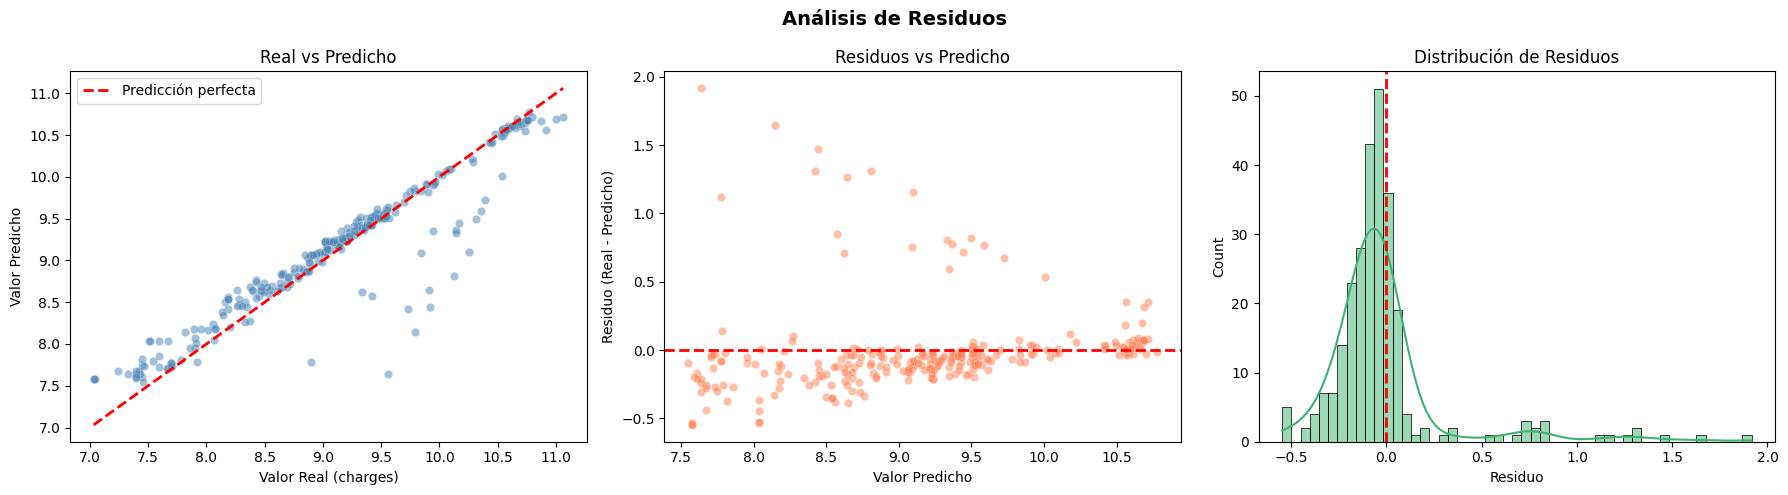

Media de residuos   : $-0.01  (idealmente cercano a 0)
Desv. estándar      : $0.33
Residuo máximo      : $1.92
Residuo mínimo      : $-0.55


In [29]:
# =========================================================
# 6. Análisis de Residuos
# =========================================================

residuos = y_test - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Análisis de Residuos", fontsize=14, fontweight="bold")

# --- Gráfico 1: Real vs Predicho ---
axes[0].scatter(y_test, y_pred, alpha=0.5, color="steelblue", edgecolors="white", linewidth=0.3)
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             "r--", linewidth=2, label="Predicción perfecta")
axes[0].set_xlabel("Valor Real (charges)")
axes[0].set_ylabel("Valor Predicho")
axes[0].set_title("Real vs Predicho")
axes[0].legend()

# --- Gráfico 2: Residuos vs Predicho ---
axes[1].scatter(y_pred, residuos, alpha=0.5, color="coral", edgecolors="white", linewidth=0.3)
axes[1].axhline(0, color="red", linestyle="--", linewidth=2)
axes[1].set_xlabel("Valor Predicho")
axes[1].set_ylabel("Residuo (Real - Predicho)")
axes[1].set_title("Residuos vs Predicho")

# --- Gráfico 3: Distribución de residuos ---
sns.histplot(residuos, kde=True, ax=axes[2], color="mediumseagreen")
axes[2].axvline(0, color="red", linestyle="--", linewidth=2)
axes[2].set_xlabel("Residuo")
axes[2].set_title("Distribución de Residuos")

plt.tight_layout()
plt.show()

# Estadísticas de residuos
print(f"Media de residuos   : ${residuos.mean():,.2f}  (idealmente cercano a 0)")
print(f"Desv. estándar      : ${residuos.std():,.2f}")
print(f"Residuo máximo      : ${residuos.max():,.2f}")
print(f"Residuo mínimo      : ${residuos.min():,.2f}")

In [30]:
# Después de predecir, deshacer el log ANTES de calcular métricas
y_pred_original = np.exp(y_pred)
y_test_original = np.exp(y_test)

mae  = mean_absolute_error(y_test_original, y_pred_original)
rmse = np.sqrt(mean_squared_error(y_test_original, y_pred_original))
mape = np.mean(np.abs((y_test_original - y_pred_original) / y_test_original)) * 100

In [31]:
print(f"\nMétricas de evaluación sobre el conjunto de test (20%):")
print(f"  • R²   : {r2:.4f}  → explica el {r2*100:.1f}% de la varianza")
print(f"  • MAE  : ${mae:,.2f}  → error promedio absoluto en dólares")
print(f"  • RMSE : ${rmse:,.2f}  → penaliza más los errores grandes")
print(f"  • MAPE : {mape:.2f}%   → error relativo promedio")


Métricas de evaluación sobre el conjunto de test (20%):
  • R²   : 0.8841  → explica el 88.4% de la varianza
  • MAE  : $1,998.72  → error promedio absoluto en dólares
  • RMSE : $4,298.07  → penaliza más los errores grandes
  • MAPE : 16.59%   → error relativo promedio


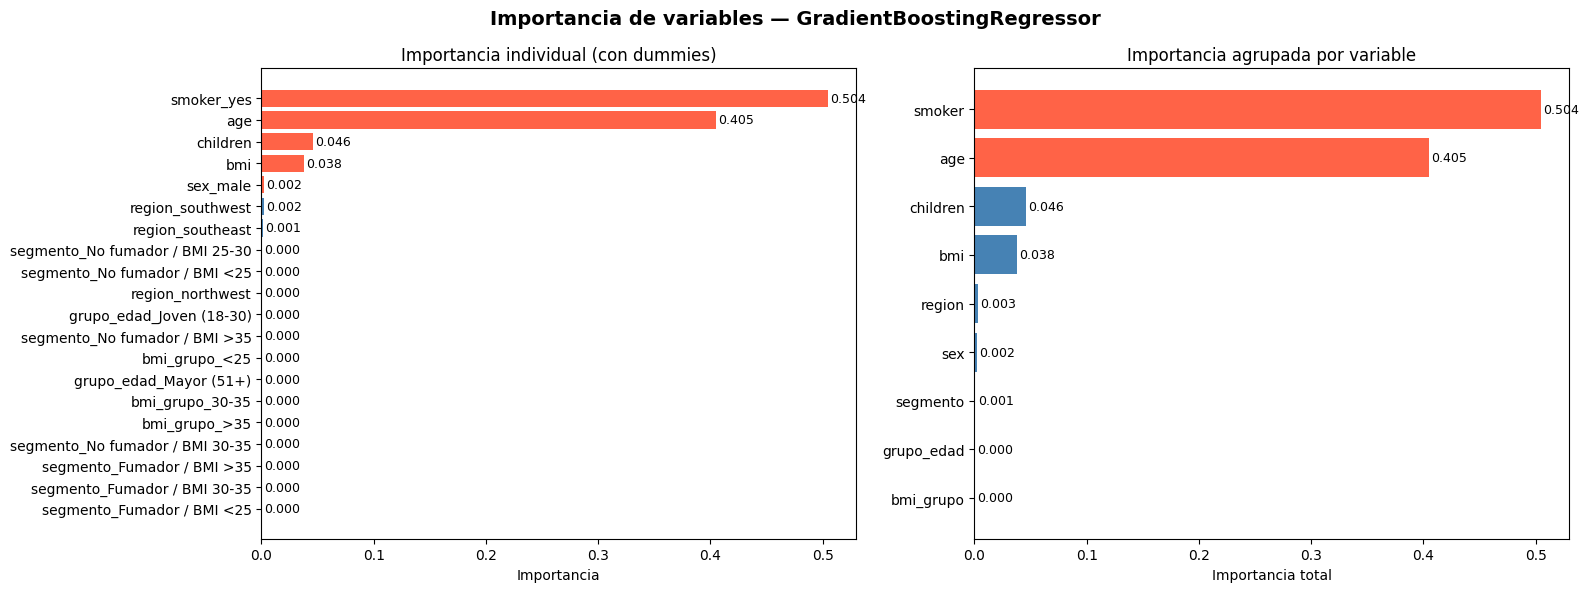


📊 Importancia agrupada (% del total):
   smoker         : 0.5043  (50.4%)
   age            : 0.4050  (40.5%)
   children       : 0.0456  (4.6%)
   bmi            : 0.0381  (3.8%)
   region         : 0.0034  (0.3%)
   sex            : 0.0025  (0.2%)
   segmento       : 0.0009  (0.1%)
   grupo_edad     : 0.0001  (0.0%)
   bmi_grupo      : 0.0000  (0.0%)

💡 Insight:
   La variable más importante es 'smoker' con 50.4% de la importancia total.
   Esto confirma que el modelo aprendió el mismo patrón que el análisis EDA.


In [32]:
# =========================================================
# INSIGHT 5: Importancia de variables (Feature Importance)
# Solo aplica si el mejor modelo es RandomForest o GradientBoosting
# =========================================================

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

best_step = grid.best_estimator_.named_steps["model"]

if hasattr(best_step, "feature_importances_"):

    # Obtener nombres de features del preprocesador
    num_features = list(num_cols)
    cat_features = list(
        grid.best_estimator_.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(cat_cols)
    )
    all_features = num_features + cat_features

    importances = best_step.feature_importances_
    fi_df = pd.DataFrame({
        "feature": all_features,
        "importance": importances
    }).sort_values("importance", ascending=True)

    # Agrupar las dummies por variable original para mayor claridad
    def map_feature(name):
        for col in cat_cols:
            if name.startswith(col):
                return col
        return name

    fi_df["feature_group"] = fi_df["feature"].apply(map_feature)
    fi_grouped = fi_df.groupby("feature_group")["importance"].sum().sort_values()

    # --- Gráfico ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle(f"Importancia de variables — {type(best_step).__name__}",
                 fontsize=14, fontweight="bold")

    # Individual (con dummies)
    colors = ["tomato" if fi_df.iloc[i]["importance"] > fi_df["importance"].quantile(0.75)
              else "steelblue" for i in range(len(fi_df))]
    axes[0].barh(fi_df["feature"], fi_df["importance"], color=colors)
    axes[0].set_title("Importancia individual (con dummies)")
    axes[0].set_xlabel("Importancia")

    # Agrupada por variable original
    colors_g = ["tomato" if v > fi_grouped.quantile(0.75) else "steelblue"
                for v in fi_grouped.values]
    axes[1].barh(fi_grouped.index, fi_grouped.values, color=colors_g)
    axes[1].set_title("Importancia agrupada por variable")
    axes[1].set_xlabel("Importancia total")

    for ax in axes:
        for i, v in enumerate(ax.containers[0]):
            width = v.get_width()
            ax.text(width + 0.002, v.get_y() + v.get_height()/2,
                    f"{width:.3f}", va="center", fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\n📊 Importancia agrupada (% del total):")
    total = fi_grouped.sum()
    for feat, val in fi_grouped.sort_values(ascending=False).items():
        print(f"   {feat:<15}: {val:.4f}  ({val/total*100:.1f}%)")

    print(f"\n💡 Insight:")
    top = fi_grouped.idxmax()
    print(f"   La variable más importante es '{top}' con {fi_grouped[top]/total*100:.1f}% de la importancia total.")
    print(f"   Esto confirma que el modelo aprendió el mismo patrón que el análisis EDA.")

else:
    print("⚠️  El mejor modelo no tiene feature_importances_ (probablemente es lineal).")
    print("   Para ver importancia en modelos lineales, podés usar los coeficientes:")

    coef = best_step.coef_
    num_features = list(num_cols)
    cat_features = list(
        grid.best_estimator_.named_steps["preprocessor"]
        .named_transformers_["cat"]
        .get_feature_names_out(cat_cols)
    )
    all_features = num_features + cat_features

    coef_df = pd.DataFrame({
        "feature": all_features,
        "coeficiente": coef
    }).sort_values("coeficiente", key=abs, ascending=True)

    plt.figure(figsize=(10, 6))
    colors = ["tomato" if c > 0 else "steelblue" for c in coef_df["coeficiente"]]
    plt.barh(coef_df["feature"], coef_df["coeficiente"], color=colors)
    plt.axvline(0, color="black", linewidth=0.8)
    plt.title("Coeficientes del modelo lineal (importancia de variables)")
    plt.xlabel("Coeficiente (escala log si usaste log(charges))")
    plt.tight_layout()
    plt.show()

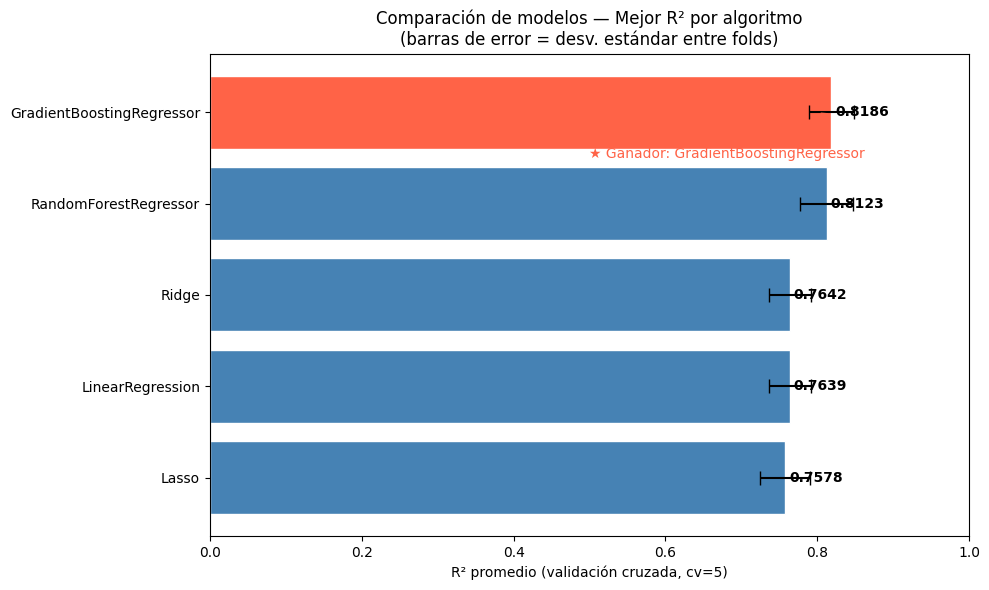


📊 Comparación de modelos (mejor resultado de cada uno):
                   Modelo  R² (CV mean)      std
                    Lasso      0.757849 0.033007
         LinearRegression      0.763925 0.027675
                    Ridge      0.764208 0.027853
    RandomForestRegressor      0.812321 0.034347
GradientBoostingRegressor      0.818591 0.030005

💡 Insight:
   El mejor modelo (GradientBoostingRegressor) supera al peor (Lasso) en 0.0607 puntos de R².
   Los modelos de ensamble (Random Forest / Gradient Boosting) superan a los lineales,
   lo que sugiere relaciones no lineales importantes en los datos.


In [33]:
# =========================================================
# INSIGHT 6: Comparación visual de todos los modelos del GridSearch
# =========================================================

results_df = pd.DataFrame(grid.cv_results_)

# Extraer nombre del modelo de cada fila
results_df["model_name"] = results_df["params"].apply(
    lambda p: type(p["model"]).__name__
)

# Mejor resultado por modelo
best_by_model = (
    results_df.groupby("model_name")["mean_test_score"]
    .max()
    .sort_values(ascending=True)
    .reset_index()
)
best_by_model.columns = ["Modelo", "R² (CV mean)"]

# Añadir desv. estándar del mejor resultado por modelo
std_by_model = results_df.loc[
    results_df.groupby("model_name")["mean_test_score"].idxmax(),
    ["model_name", "std_test_score"]
].set_index("model_name")

best_by_model["std"] = best_by_model["Modelo"].map(std_by_model["std_test_score"])

# --- Gráfico ---
fig, ax = plt.subplots(figsize=(10, 6))

colors = ["tomato" if m == best_by_model.iloc[-1]["Modelo"] else "steelblue"
          for m in best_by_model["Modelo"]]

bars = ax.barh(best_by_model["Modelo"], best_by_model["R² (CV mean)"],
               xerr=best_by_model["std"], color=colors,
               capsize=5, edgecolor="white")

ax.set_xlabel("R² promedio (validación cruzada, cv=5)")
ax.set_title("Comparación de modelos — Mejor R² por algoritmo\n(barras de error = desv. estándar entre folds)")
ax.set_xlim(0, 1)

# Etiquetas de valor
for bar, val in zip(bars, best_by_model["R² (CV mean)"]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", fontsize=10, fontweight="bold")

# Leyenda del ganador
mejor = best_by_model.iloc[-1]["Modelo"]
ax.annotate(f"★ Ganador: {mejor}", xy=(best_by_model.iloc[-1]["R² (CV mean)"], len(best_by_model)-1),
            xytext=(0.5, len(best_by_model)-1.5),
            fontsize=10, color="tomato",
            arrowprops=dict(arrowstyle="->", color="tomato"))

plt.tight_layout()
plt.show()

# --- Tabla completa ---
print("\n📊 Comparación de modelos (mejor resultado de cada uno):")
print(best_by_model.to_string(index=False))

print(f"\n💡 Insight:")
peor  = best_by_model.iloc[0]["Modelo"]
mejor = best_by_model.iloc[-1]["Modelo"]
diff  = best_by_model.iloc[-1]["R² (CV mean)"] - best_by_model.iloc[0]["R² (CV mean)"]
print(f"   El mejor modelo ({mejor}) supera al peor ({peor}) en {diff:.4f} puntos de R².")
print(f"   Los modelos de ensamble (Random Forest / Gradient Boosting) superan a los lineales,")
print(f"   lo que sugiere relaciones no lineales importantes en los datos.")

In [42]:
# =========================================================
# 🏆 FINAL MODEL RANKING
# =========================================================

# Convertir resultados del GridSearch a DataFrame
cv_results = pd.DataFrame(grid.cv_results_)

# =========================================================
# LIMPIAR NOMBRES DE MODELOS
# =========================================================

def clean_model_name(model):
    model = str(model)

    if "GradientBoostingRegressor" in model:
        return "Gradient Boosting"

    elif "RandomForestRegressor" in model:
        return "Random Forest"

    elif "LinearRegression" in model:
        return "Linear Regression"

    elif "Ridge" in model:
        return "Ridge Regression"

    elif "Lasso" in model:
        return "Lasso Regression"

    return model

cv_results["Model"] = cv_results["param_model"].apply(clean_model_name)

# =========================================================
# QUEDARSE CON LA MEJOR VERSIÓN DE CADA MODELO
# =========================================================

best_models = (
    cv_results
    .sort_values(by="mean_test_score", ascending=False)
    .drop_duplicates(subset="Model")
)

# =========================================================
# CREAR TABLA FINAL
# =========================================================

ranking = best_models[
    [
        "Model",
        "mean_test_score",
        "std_test_score"
    ]
].copy()

ranking.columns = [
    "Model",
    "Mean CV R²",
    "Std Dev"
]

# =========================================================
# ORDENAR Y CREAR NUEVO RANKING
# =========================================================

ranking = ranking.sort_values(
    by="Mean CV R²",
    ascending=False
).reset_index(drop=True)

ranking.index += 1
ranking.index.name = "Rank"

# =========================================================
# ESTILO FINAL
# =========================================================

display(
    ranking.style
    .background_gradient(
        subset=["Mean CV R²"],
        cmap="Greens"
    )
    .format({
        "Mean CV R²": "{:.4f}",
        "Std Dev": "{:.4f}"
    })
    .set_properties(**{
        'text-align': 'center',
        'padding': '10px'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('font-size', '14px'),
                ('text-align', 'center'),
                ('font-weight', 'bold')
            ]
        }
    ])
    .set_caption("🏆 Final Model Ranking")
)

,Model,Mean CV R²,Std Dev
Rank,,,
1,Gradient Boosting,0.8186,0.0300
2,Random Forest,0.8123,0.0343
3,Ridge Regression,0.7642,0.0279
4,Linear Regression,0.7639,0.0277
5,Lasso Regression,0.7578,0.0330
